In [1]:
import pandas as pd

In [2]:
random_state = 2020
embedding_dims = 32
batch_size = 32
epochs = 64
train_test_split = 0.3
dataset_training_frac = 1
agency_transactions_cuttoff = 30

#### Objective:
Train a embedding model using the triplet loss to generate transaction vectors of `embeddging_dims`.

#### Depends on:

In [ ]:
df_fname = "./data/05-dataframe-with-vectors.parquet"

#### Generates:

In [ ]:
triplet_loss_model_fname = "./data/triplet_loss_model_4_agencies.pth"

-------------------

In [3]:
df = pd.read_parquet(df_fname)  # this takes 4GB

In [4]:
# DEPARTMENT OF TRANSPORTATION|34500
# DEPARTMENT OF CORRECTIONS|13100
# DEPARTMENT OF TOURISM AND RECREATION|56600
# DEPARTMENT OF VETERANS AFFAIRS|65000

df = df[df.agency_number.isin([34500, 13100, 56600, 65000])]

In [5]:
df.head()

,cohort,agency_number,agency_name,holder_last_name,holder_first_initial,amount,vendor,mcc,parsed_amount,transaction_date,...,mcc_vector_758,mcc_vector_759,mcc_vector_760,mcc_vector_761,mcc_vector_762,mcc_vector_763,mcc_vector_764,mcc_vector_765,mcc_vector_766,mcc_vector_767
77998,201307,13100,DEPARTMENT OF CORRECTIONS,Briscoe,C,179.8,WW GRAINGER,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,5.191845,2013-07-25,...,-0.030737,0.006508,0.027860,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
77999,201307,13100,DEPARTMENT OF CORRECTIONS,Campbell,B,307.71,LOWES #02854,HOME SUPPLY WAREHOUSE STORES,5.729158,2013-07-24,...,-0.001497,-0.017025,0.025489,0.002128,-0.002501,-0.015514,0.026597,0.015481,-0.083886,-0.013023
78000,201307,13100,DEPARTMENT OF CORRECTIONS,Coats,R,885,YORK INTL OKC,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,6.785588,2013-07-25,...,-0.030737,0.006508,0.027860,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
78001,201307,13100,DEPARTMENT OF CORRECTIONS,Darrough,M,27.14,WANETTE TRACTOR & SUPPLY,"MISC. AUTOMOTIVE,AIRCRAFT,AND FARM EQUIPMENT D...",3.301009,2013-07-25,...,-0.013766,0.006793,0.077863,-0.007351,-0.044780,0.008202,-0.041866,-0.003140,-0.060051,-0.033822
78002,201307,13100,DEPARTMENT OF CORRECTIONS,Darrough,M,102,INT CEDAR CREEK VET CLINI,VETERINARY SERVICES,4.624973,2013-07-25,...,-0.028200,0.023716,0.055489,-0.040634,-0.016646,-0.042075,-0.030321,0.001595,0.028473,-0.037551


In [6]:
df = df.sample(frac=dataset_training_frac, random_state=random_state)

In [7]:
drop_cols = [
    "cohort",
    "agency_name",
    "holder_last_name",
    "holder_first_initial",
    "amount",
    "vendor",
    "mcc",
    "transaction_date",
    "posted_date",
]  # keep 'agency_number', 'parsed_amount' and repr of mcc and vendor
label_col = "agency_number"

In [8]:
df.drop(drop_cols, axis=1, inplace=True)

In [9]:
training_cols = list(set(df.columns).difference(label_col))

In [10]:
# adapted from: https://www.kaggle.com/code/hirotaka0122/triplet-loss-with-pytorch

In [11]:
import torch
import numpy as np
import random
from sklearn import model_selection
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

In [12]:
X_train, X_test = model_selection.train_test_split(
    df, test_size=train_test_split, random_state=random_state
)

In [13]:
del df

In [14]:
torch.manual_seed(random_state)
np.random.seed(random_state)
random.seed(random_state)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.cuda.get_device_name()

In [15]:
device

device(type='cuda')

In [16]:
X_test.head()

,agency_number,parsed_amount,vendor_vector_0,vendor_vector_1,vendor_vector_2,vendor_vector_3,vendor_vector_4,vendor_vector_5,vendor_vector_6,vendor_vector_7,...,mcc_vector_758,mcc_vector_759,mcc_vector_760,mcc_vector_761,mcc_vector_762,mcc_vector_763,mcc_vector_764,mcc_vector_765,mcc_vector_766,mcc_vector_767
147656,65000,4.094178,-0.024702,-0.013977,-0.008087,0.030186,-0.002276,0.035975,0.037765,0.057471,...,-0.014807,-0.026985,0.092466,-0.004817,-0.014987,-0.028285,-0.013469,-0.012369,-0.055801,-0.047973
133338,56600,4.747190,-0.017904,-0.013190,0.011119,0.019121,-0.007400,0.004660,-0.006010,0.021672,...,-0.037394,-0.000532,-0.015767,0.000562,-0.021355,-0.045887,-0.057664,-0.020277,-0.006593,0.037357
147770,65000,3.355851,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,...,-0.012502,-0.034145,0.039250,-0.011310,-0.058575,-0.048255,-0.028293,-0.012003,-0.015341,-0.028219
409535,65000,4.139955,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,...,-0.022811,-0.017667,0.045654,-0.003255,-0.052636,-0.072668,-0.011354,0.027289,-0.032321,-0.000313
318482,65000,7.364940,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,...,-0.021746,-0.023560,-0.023743,-0.011229,-0.005407,0.034474,-0.084553,-0.009818,-0.075148,0.001058


In [17]:
X_train.head()

,agency_number,parsed_amount,vendor_vector_0,vendor_vector_1,vendor_vector_2,vendor_vector_3,vendor_vector_4,vendor_vector_5,vendor_vector_6,vendor_vector_7,...,mcc_vector_758,mcc_vector_759,mcc_vector_760,mcc_vector_761,mcc_vector_762,mcc_vector_763,mcc_vector_764,mcc_vector_765,mcc_vector_766,mcc_vector_767
112513,34500,5.333347,0.002662,0.049817,-0.014760,-0.014084,0.010705,0.038575,0.053983,0.006229,...,-0.036014,-0.049133,0.000140,0.025179,0.002835,-0.019115,0.019838,-0.005031,-0.080640,0.010850
151322,65000,6.705566,-0.020918,-0.011576,-0.005866,-0.034069,0.026064,-0.004863,0.067735,-0.012302,...,-0.029486,0.017108,0.060356,-0.012803,-0.013699,0.037252,-0.040759,0.004266,-0.037517,-0.013696
108547,34500,5.041229,0.008680,-0.008850,-0.005182,-0.019806,0.006723,0.024422,0.071407,0.011327,...,-0.030737,0.006508,0.027860,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
81476,13100,3.688879,0.012147,0.021508,-0.007825,-0.007432,-0.002976,0.015324,0.052413,0.011674,...,-0.030737,0.006508,0.027860,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251
110825,34500,6.921895,0.008680,-0.008850,-0.005182,-0.019806,0.006723,0.024422,0.071407,0.011327,...,-0.030737,0.006508,0.027860,0.017615,0.010312,-0.010796,-0.041277,-0.017827,-0.071669,-0.017251


In [18]:
input_dim = len(X_train.columns) - 1

In [19]:
class TransactionsDataset(Dataset):
    def __init__(self, df, training_cols, train=True, agency_transactions_cuttoff=30):
        agency_number_transaction_counts = df.groupby("agency_number").count()[
            "parsed_amount"
        ]
        excluded_agencies = agency_number_transaction_counts[
            agency_number_transaction_counts < agency_transactions_cuttoff
        ]
        self.transactions = df[~df["agency_number"].isin(excluded_agencies.index)]

        self.transactions = self.transactions.set_index(
            "agency_number", drop=False
        ).sort_index()

        self.is_train = train
        self.training_cols = training_cols
        self.agency_numbers = set(self.transactions["agency_number"].unique())

    def __len__(self):
        return len(self.transactions)

    def __getitem__(self, item):
        anchor_transaction = self.transactions.iloc[item]
        # print('anchor', anchor_transaction.head())

        if self.is_train:
            anchor_label = anchor_transaction["agency_number"]

            negative_agency = np.random.choice(
                list(self.agency_numbers.difference([anchor_label]))
            )

            anchor_transaction = anchor_transaction.drop(
                "agency_number", axis="rows"
            ).values.astype("float32")

            positive_transactions = self.transactions.loc[anchor_label]

            positive_transaction = (
                positive_transactions.sample(n=1)
                .drop("agency_number", axis="columns")
                .values[0]
                .astype("float32")
            )

            negative_transaction = (
                self.transactions.loc[negative_agency]
                .sample(n=1)
                .drop("agency_number", axis="columns")
                .values[0]
                .astype("float32")
            )

            return (
                anchor_transaction,
                positive_transaction,
                negative_transaction,
                anchor_label,
            )
        else:
            return (
                anchor_transaction.drop("agency_number", axis="rows").values.astype(
                    "float32"
                ),
                0,
                0,
                anchor_transaction["agency_number"],
            )

In [20]:
train_ds = TransactionsDataset(
    X_train,
    training_cols,
    train=True,
    agency_transactions_cuttoff=agency_transactions_cuttoff,
)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)

In [21]:
test_ds = TransactionsDataset(
    X_test,
    training_cols,
    train=False,
    agency_transactions_cuttoff=agency_transactions_cuttoff,
)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4)

In [22]:
%load_ext line_profiler

In [23]:
def find_triplet(item):
    anchor_transaction = train_ds.transactions.iloc[item]

    anchor_label = anchor_transaction["agency_number"]

    negative_agency = np.random.choice(
        list(train_ds.agency_numbers.difference([anchor_label]))
    )

    anchor_transaction = anchor_transaction.drop(
        "agency_number", axis="rows"
    ).values.astype("float32")

    positive_transactions = train_ds.transactions.loc[anchor_label]

    positive_transaction = (
        positive_transactions.sample(n=1)
        .drop("agency_number", axis="columns")
        .values[0]
        .astype("float32")
    )

    negative_transaction = (
        train_ds.transactions.loc[negative_agency]
        .sample(n=1)
        .drop("agency_number", axis="columns")
        .values[0]
        .astype("float32")
    )

In [24]:
%lprun -f find_triplet [find_triplet(i) for i in range(3000,3100)]

Timer unit: 1e-09 s

Total time: 0.425268 s
File: /tmp/ipykernel_2976/1827459464.py
Function: find_triplet at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def find_triplet(item):
     2       100  131103806.0    1e+06     30.8      anchor_transaction = train_ds.transactions.iloc[item]
     3                                           
     4       100    1615374.0  16153.7      0.4      anchor_label = anchor_transaction['agency_number']
     5                                           
     6       100    4193019.0  41930.2      1.0      negative_agency = np.random.choice(list(train_ds.agency_numbers.difference([anchor_label])))
     7                                               
     8       100   46756465.0 467564.7     11.0      anchor_transaction = anchor_transaction.drop('agency_number', axis='rows').values.astype('float32')
     9                                           
    10       100   15575396.0 15

In [25]:
# nn.init.xavier_uniform_(w, gain=nn.init.calculate_gain('relu'))


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain("relu"))
        m.bias.data.fill_(0.01)


class Network(nn.Module):
    def __init__(self, input_dim=1537, emb_dim=32):
        super(Network, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.PReLU(),
            nn.Linear(input_dim, 1024),
            nn.PReLU(),
            nn.Linear(1024, 1024),
            nn.PReLU(),
            nn.Linear(1024, 128),
            nn.PReLU(),
            nn.Linear(128, 64),
            nn.PReLU(),
            nn.Linear(64, 64),
            nn.PReLU(),
            nn.Linear(64, emb_dim),
        )

        self.fc.apply(init_weights)

    def forward(self, x):
        x = self.fc(x)
        return x

In [26]:
model = Network(input_dim, embedding_dims)
model = torch.jit.script(model).to(device)

# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = torch.jit.script(nn.TripletMarginLoss())

In [27]:
%timeit train_ds.__getitem__(200)

3 ms ± 46.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [28]:
# %%prun -s cumulative

# next(iter(train_loader))

In [29]:
X_train.shape

(43902, 1538)

In [30]:
model.train()
for epoch in tqdm(range(epochs), desc="Epochs"):
    running_loss = []
    for step, (
        anchor_transaction,
        positive_transaction,
        negative_transaction,
        anchor_label,
    ) in enumerate(tqdm(train_loader, desc="Training", leave=False)):
        anchor = anchor_transaction.to(device)
        positive = positive_transaction.to(device)
        negative = negative_transaction.to(device)

        # print("anchor", anchor)
        # print("positive", positive)
        # print("negative", negative)

        optimizer.zero_grad()

        anchor_out = model(anchor)
        positive_out = model(positive)
        negative_out = model(negative)

        # print("anchor_out", anchor_out)
        # print("positive_out", positive_out)
        # print("negative_out", negative_out)

        loss = criterion(anchor_out, positive_out, negative_out)

        # print("loss", loss)

        loss.backward()
        optimizer.step()

        # break

        running_loss.append(loss.cpu().detach().numpy())
    print(
        "Epoch: {}/{} - Loss: {:.4f}".format(epoch + 1, epochs, np.mean(running_loss))
    )
    # break

Epochs:   0%|          | 0/64 [00:00<?, ?it/s]

Training:   0%|          | 0/1372 [00:00<?, ?it/s]

Epoch: 1/64 - Loss: 0.9428


Training:   0%|          | 0/1372 [00:00<?, ?it/s]

Epoch: 2/64 - Loss: 0.9144


...

Epoch: 62/64 - Loss: 0.8306


Training:   0%|          | 0/1372 [00:00<?, ?it/s]

Epoch: 63/64 - Loss: 0.8353


Training:   0%|          | 0/1372 [00:00<?, ?it/s]

Epoch: 64/64 - Loss: 0.8383


In [31]:
# anchor.shape

In [32]:
# (model(torch.rand(1, 1537).to(device)) - model(anchor)).sum()

In [33]:
# model(anchor)

In [34]:
# for p in model.parameters():
#     print(p.shape)
#     print(p.grad)
# #small gradients

In [35]:
torch.save(model.state_dict(), triplet_loss_model_fname)

In [36]:
import matplotlib.pyplot as plt

In [37]:
train_results = []
labels = []

model.eval()
with torch.no_grad():
    for transaction, _, _, label in tqdm(test_loader):
        train_results.append(model(transaction.to(device)).cpu().numpy())
        labels.append(label)

train_results = np.concatenate(train_results)
labels = np.concatenate(labels)
train_results.shape

  0%|          | 0/588 [00:00<?, ?it/s]

(18816, 32)

In [38]:
train_results.shape

(18816, 32)

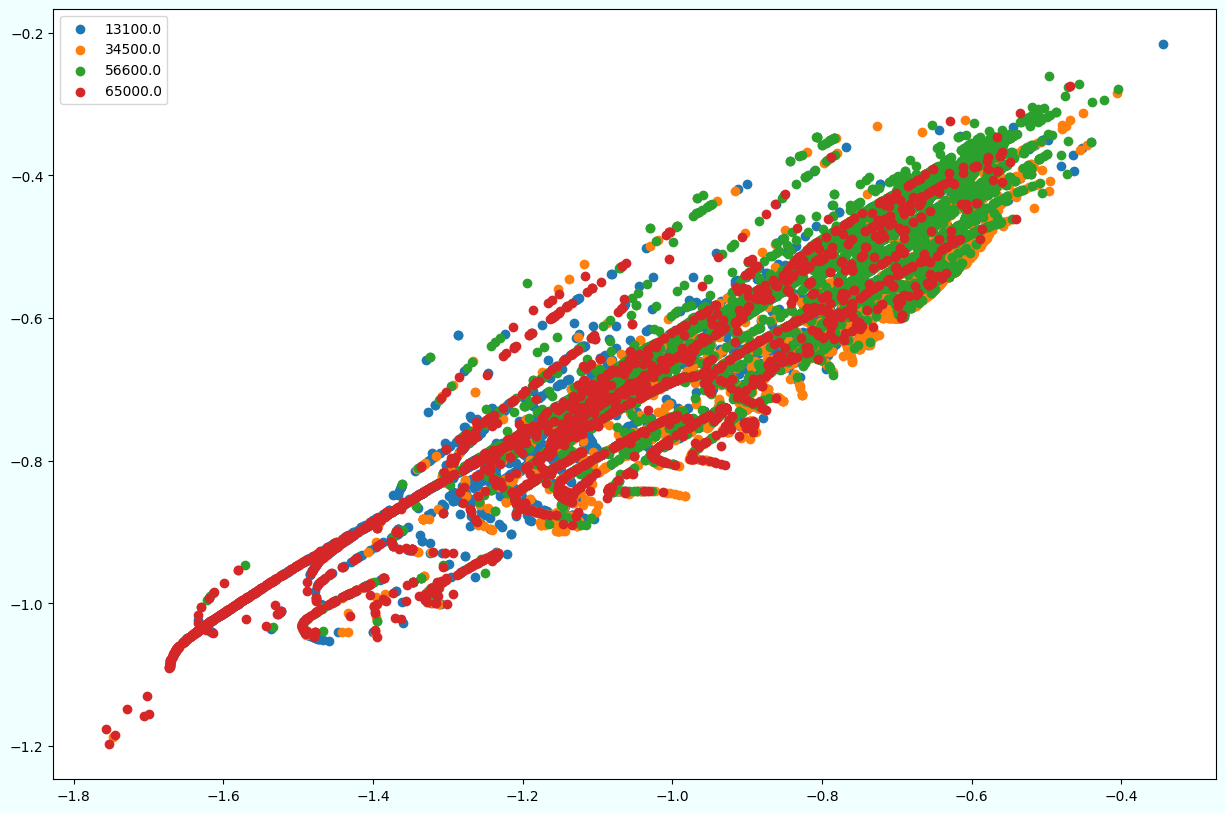

In [39]:
plt.figure(figsize=(15, 10), facecolor="azure")
for label in np.unique(labels):
    tmp = train_results[labels == label]
    plt.scatter(tmp[:, 2], tmp[:, 3], label=label)

plt.legend()
plt.show()